<a href="https://colab.research.google.com/github/KrithikChidM/PrmlLab/blob/main/LAB5/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

##EX1

###Isotopic Covariance

Accuracy: 0.9396666666666667
[[1863   98   39]
 [  81 1859   60]
 [  40   44 1916]]


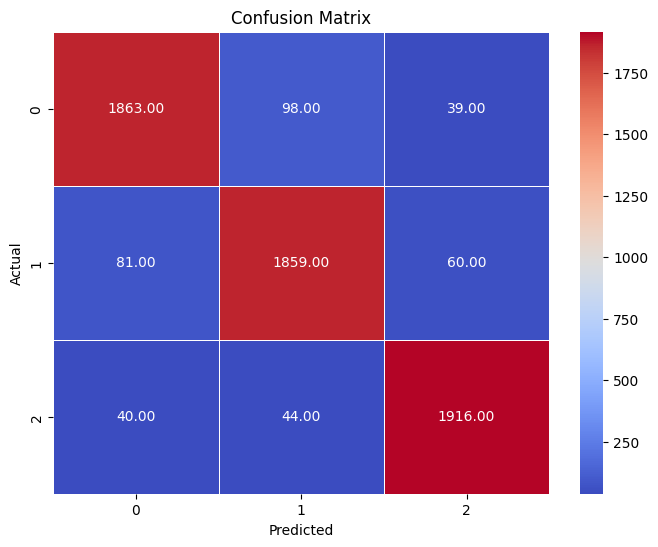

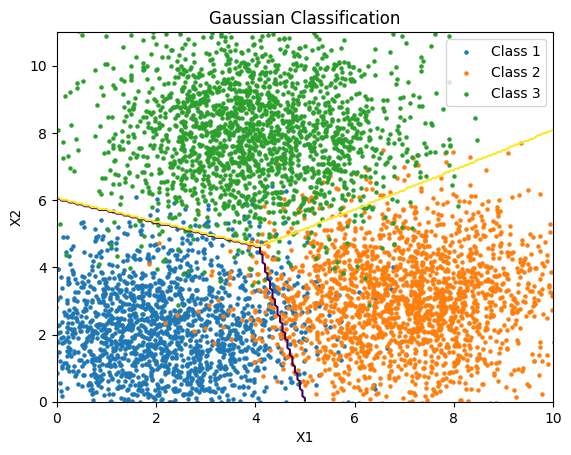

In [17]:
#same
np.random.seed(42)

n = 10000
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [(1.5**2)*np.eye(2), (1.5**2)*np.eye(2), (1.5**2)*np.eye(2)]

X = np.vstack([np.random.multivariate_normal(means[i], covs[i], n) for i in range(3)])
y = np.repeat([0,1,2], n)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i], rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx, yy = np.meshgrid(np.linspace(0,10,200), np.linspace(0,11,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(), yy.ravel()]]).reshape(xx.shape)

for i in range(3):
    plt.scatter(Xte[yte==i,0], Xte[yte==i,1], s=5, label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.contour(xx, yy, Z, levels=[0.5, 1.5])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend()
plt.show()

[[ 2.74507123  1.79260355]
 [ 2.97153281  4.28454478]
 [ 1.64876994  1.64879456]
 ...
 [ 5.06748534  6.59628708]
 [ 1.80191143  8.28202027]
 [-0.36394568  7.98720483]] [0 0 0 ... 2 2 2]
Accuracy: 0.952
[[1888   54   58]
 [  20 1948   32]
 [  77   47 1876]]


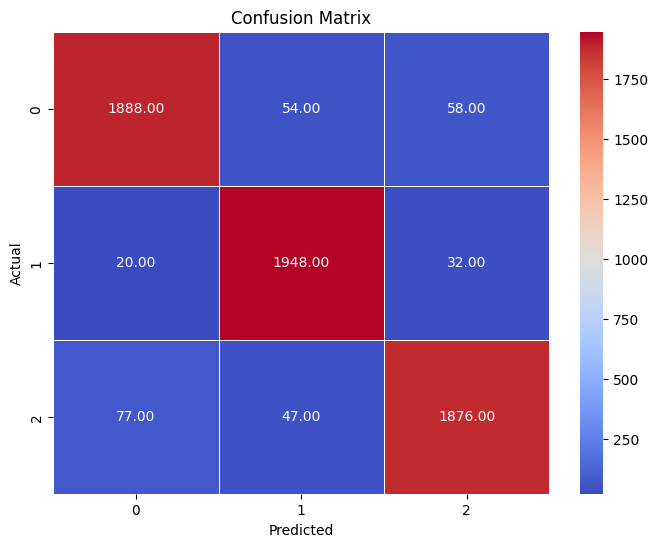

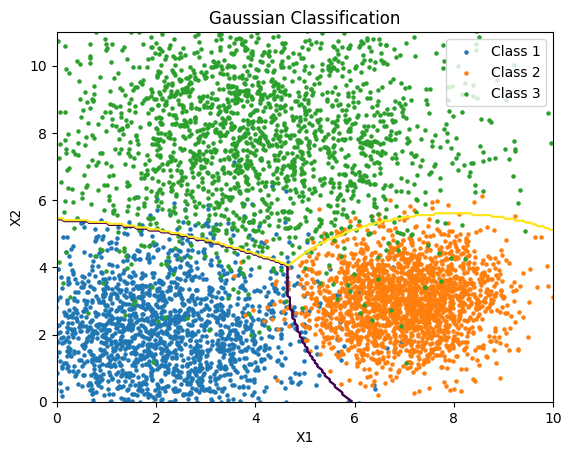

In [24]:
#same
np.random.seed(42)

n = 10000
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [(1.5**2)*np.eye(2), (1**2)*np.eye(2), (2**2)*np.eye(2)]

X = np.vstack([np.random.multivariate_normal(means[i], covs[i], n) for i in range(3)])
y = np.repeat([0,1,2], n)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i], rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx, yy = np.meshgrid(np.linspace(0,10,200), np.linspace(0,11,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(), yy.ravel()]]).reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5,1.5])
for i in range(3):
    plt.scatter(Xte[yte==i,0], Xte[yte==i,1], s=5, label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.contour(xx, yy, Z, levels=[0.5, 1.5])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("Gaussian Classification")
plt.legend()
plt.show()

###Diagonal Covariance

Accuracy: 0.9595
[[1933    9   58]
 [   9 1943   48]
 [  84   35 1881]]


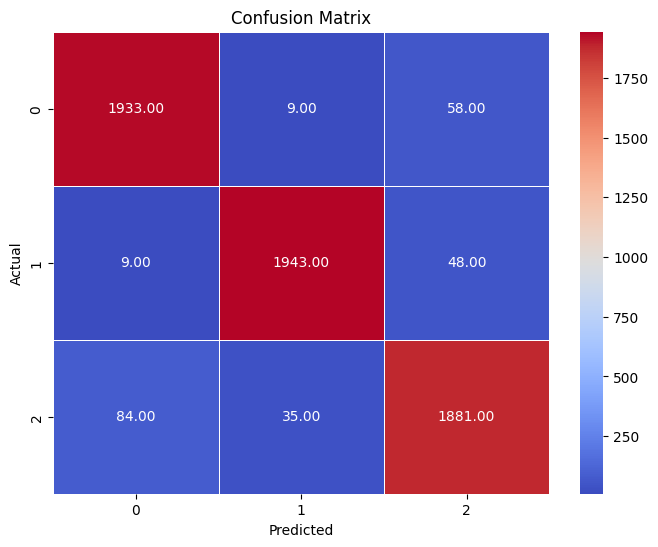

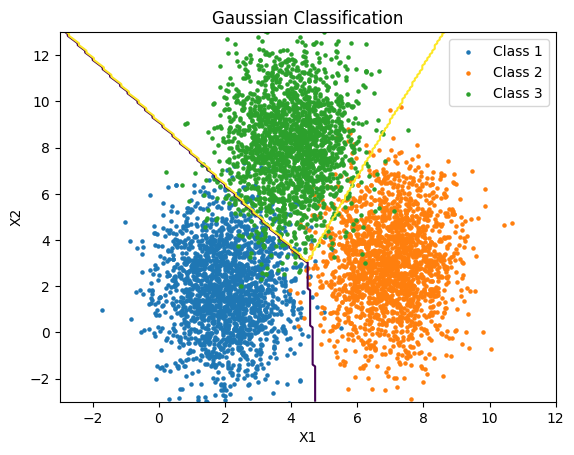

In [19]:
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [np.diag([1,4]), np.diag([1,4]), np.diag([1,4])]

X = np.vstack([np.random.multivariate_normal(means[i], covs[i], n) for i in range(3)])
y = np.repeat([0,1,2], n)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i],rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx,yy = np.meshgrid(np.linspace(-3,12,200),np.linspace(-3,13,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(),yy.ravel()]]).reshape(xx.shape)

for i in range(3):
    plt.scatter(Xte[yte==i,0],Xte[yte==i,1],s=5,label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.contour(xx, yy, Z, levels=[0.5, 1.5])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend(); plt.show()

Accuracy: 0.9425
[[1885   43   72]
 [ 104 1874   22]
 [  64   40 1896]]


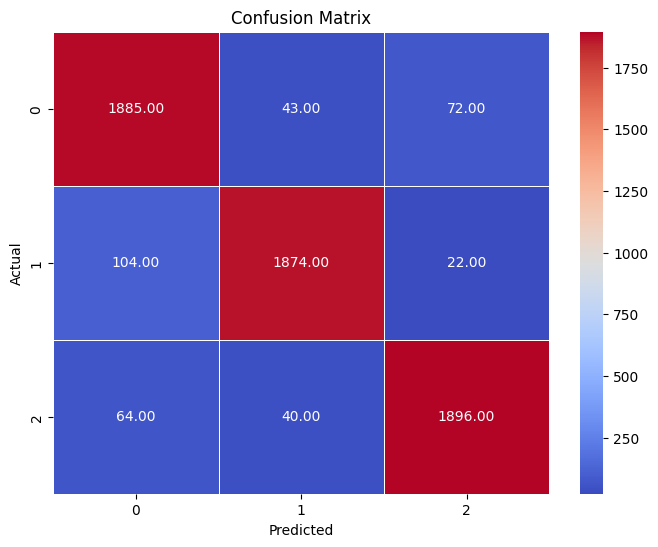

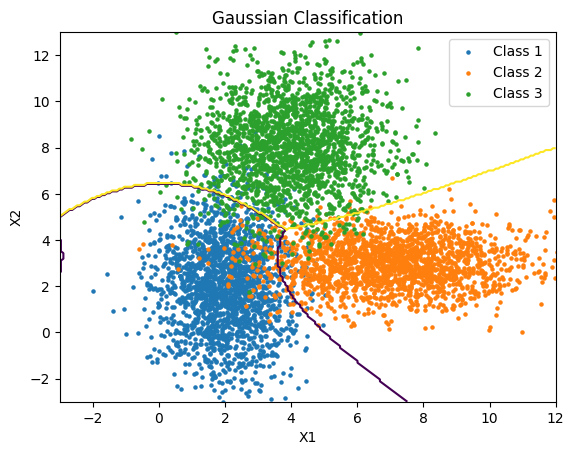

In [20]:
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [np.diag([1,4]), np.diag([4,1]), np.diag([2,3])]

X = np.vstack([np.random.multivariate_normal(means[i], covs[i], n) for i in range(3)])
y = np.repeat([0,1,2], n)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i],rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx,yy = np.meshgrid(np.linspace(-3,12,200),np.linspace(-3,13,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(),yy.ravel()]]).reshape(xx.shape)

for i in range(3):
    plt.scatter(Xte[yte==i,0],Xte[yte==i,1],s=5,label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.contour(xx, yy, Z, levels=[0.5, 1.5])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend(); plt.show()

###Full Covariance

Accuracy: 0.9418333333333333
[[1845   67   88]
 [  69 1919   12]
 [ 100   13 1887]]


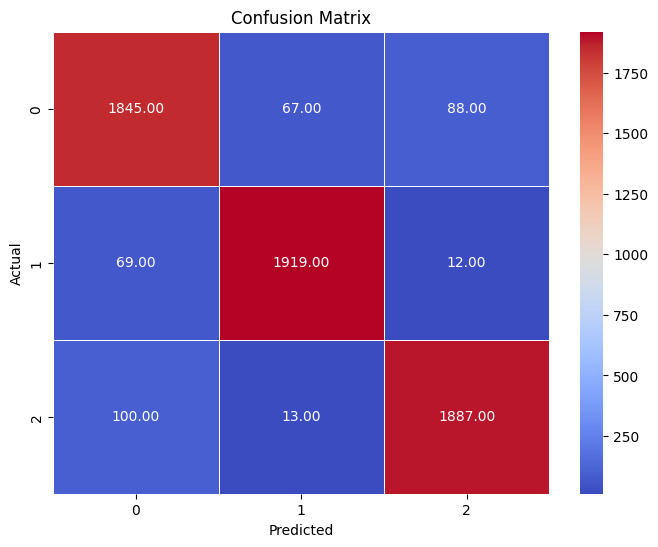

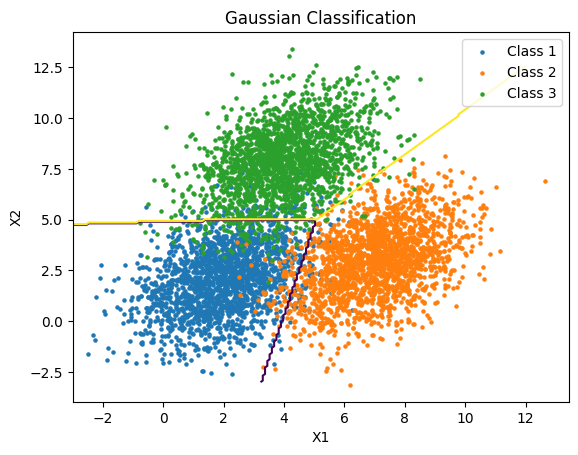

In [36]:
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [np.array([[2,1],[1,3]]), np.array([[2,1],[1,3]]), np.array([[2,1],[1,3]])]

X = np.vstack([np.random.multivariate_normal(means[i],covs[i],n) for i in range(3)])
y = np.repeat([0,1,2],n)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.2,stratify=y,random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i],rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-.5*d@np.linalg.inv(S[i])@d-.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)


plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx,yy = np.meshgrid(np.linspace(-3,12,200),np.linspace(-3,13,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(),yy.ravel()]]).reshape(xx.shape)

plt.contour(xx,yy,Z,levels=[.5,1.5])
for i in range(3):
    plt.scatter(Xte[yte==i,0],Xte[yte==i,1],s=5,label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.legend(); plt.show()

Accuracy: 0.9515
[[1897   43   60]
 [  64 1912   24]
 [  63   37 1900]]


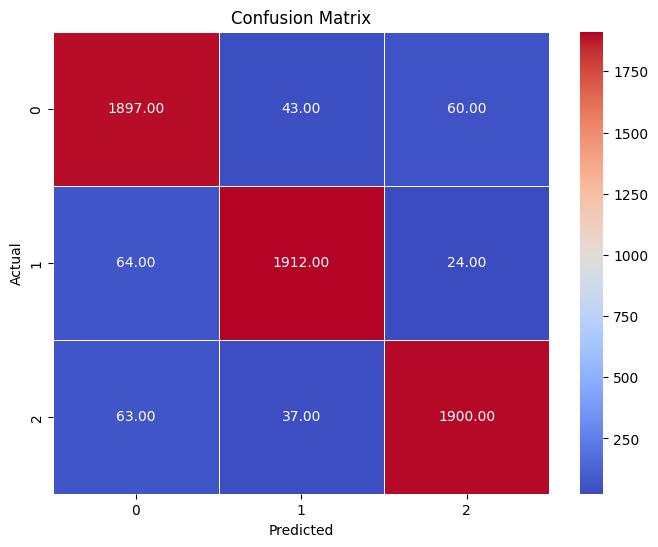

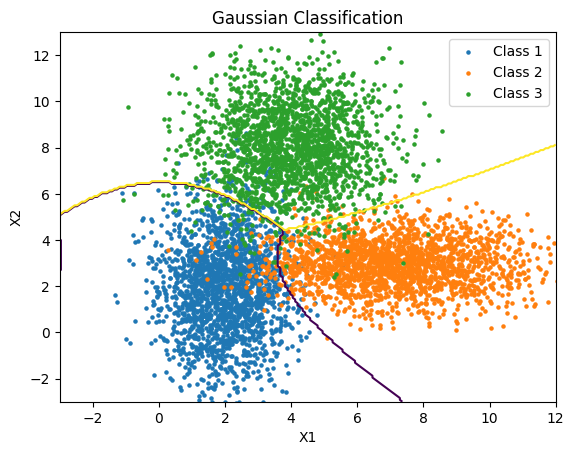

In [22]:
means = [np.array([2,2]), np.array([7,3]), np.array([4,8])]
covs = [np.diag([1,4]), np.diag([4,1]), np.diag([2,3])]

X = np.vstack([np.random.multivariate_normal(means[i], covs[i], n) for i in range(3)])
y = np.repeat([0,1,2], n)

Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i],rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,  # Show numbers inside the cells
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx,yy = np.meshgrid(np.linspace(-3,12,200),np.linspace(-3,13,200))
Z = np.array([classify(x) for x in np.c_[xx.ravel(),yy.ravel()]]).reshape(xx.shape)

for i in range(3):
    plt.scatter(Xte[yte==i,0],Xte[yte==i,1],s=5,label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.contour(xx, yy, Z, levels=[0.5, 1.5])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend(); plt.show()

##EX2

Accuracy: 0.78
[[88  8  4]
 [16 80  4]
 [27  7 66]]


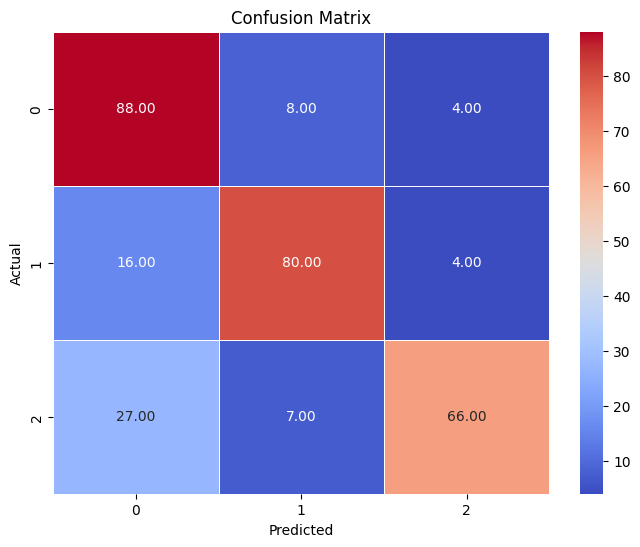

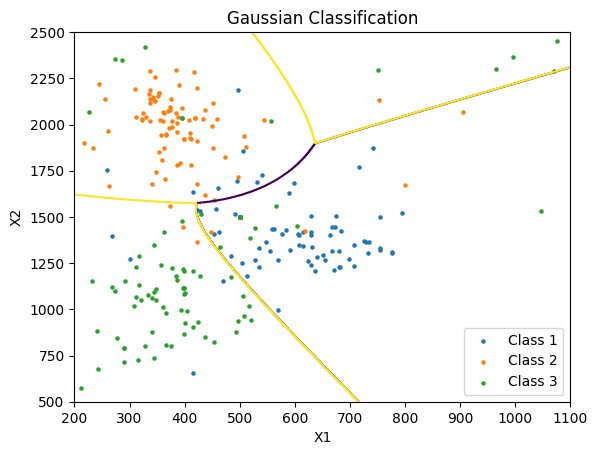

In [35]:
data = np.loadtxt("/content/drive/MyDrive/Krithik SNU/HAM/trian.txt", delimiter=",")

Xtr = data[:, :2]
ytr = data[:, 2]-1

data = np.loadtxt("/content/drive/MyDrive/Krithik SNU/HAM/dev.txt", delimiter=",")

Xte = data[:, :2]
yte = data[:, 2]-1

mu = [Xtr[ytr==i].mean(axis=0) for i in range(3)]
S = [np.cov(Xtr[ytr==i], rowvar=False) for i in range(3)]

def classify(x):
    p = []
    for i in range(3):
        d = x-mu[i]
        p.append(-0.5*d@np.linalg.inv(S[i])@d-0.5*np.log(np.linalg.det(S[i])))
    return np.argmax(p)

yp = np.array([classify(x) for x in Xte])

data = confusion_matrix(yte, yp)
print("Accuracy:", np.mean(yp == yte))
print(data)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data,
    annot=True,
    fmt=".2f",  # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'viridis', 'plasma', 'coolwarm')
    linewidths=0.5,  # Add subtle lines between cells
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

xx, yy = np.meshgrid(np.linspace(200,1100,900), np.linspace(500,2500,1000))
Z = np.array([classify(x) for x in np.c_[xx.ravel(), yy.ravel()]]).reshape(xx.shape)

for i in range(3):
    plt.scatter(Xte[yte==i,0], Xte[yte==i,1], s=5, label=f"Class {i+1}")
plt.xlabel("X1"); plt.ylabel("X2")
plt.title("Gaussian Classification")
plt.contour(xx, yy, Z, levels=[0.5, 1.5])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend()
plt.show()